In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [62]:
df = pd.read_csv("/content/AIML Dataset.csv")

In [63]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [64]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4882982 entries, 0 to 4882981
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 409.8+ MB


In [65]:

df["isFraud"].value_counts()

,count
isFraud,
0.0,4879112
1.0,3869


In [66]:
df["isFlaggedFraud"].value_counts()

,count
isFlaggedFraud,
0.0,4882978
1.0,3


In [67]:
df.isnull().sum().sum()

np.int64(4)

In [68]:
df.shape[0]

4882982

In [69]:
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100,2)

np.float64(0.08)

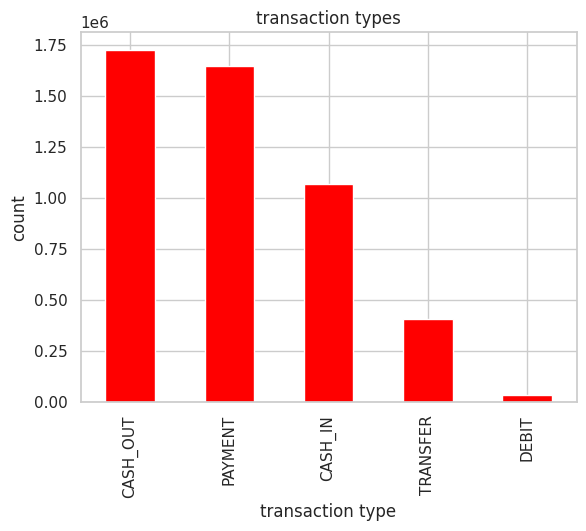

In [70]:
df["type"].value_counts().plot(kind="bar", title="transaction types", color = "red")
plt.xlabel("transaction type")
plt.ylabel("count")
plt.show()

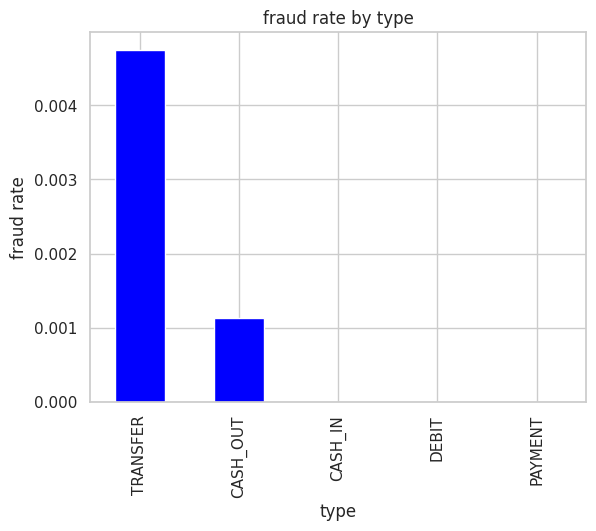

In [71]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar",title="fraud rate by type", color ="blue")
plt.ylabel("fraud rate")
plt.show()

In [72]:
df["amount"].describe().astype(int)

,amount
count,4882982
mean,180934
std,647771
min,0
25%,13158
50%,75293
75%,209305
max,92445516


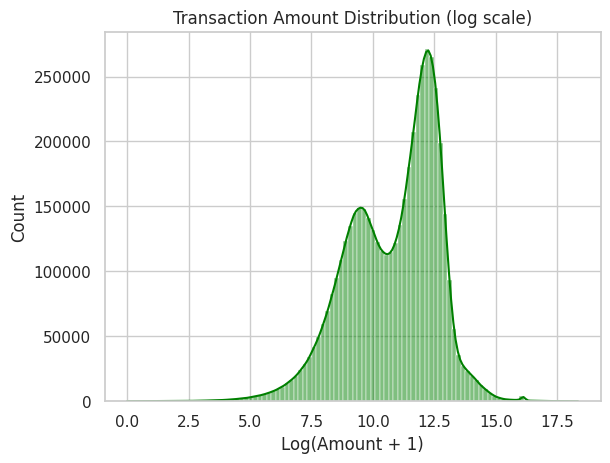

In [73]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde = True, color = "green")
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("Log(Amount + 1)")
plt.show()

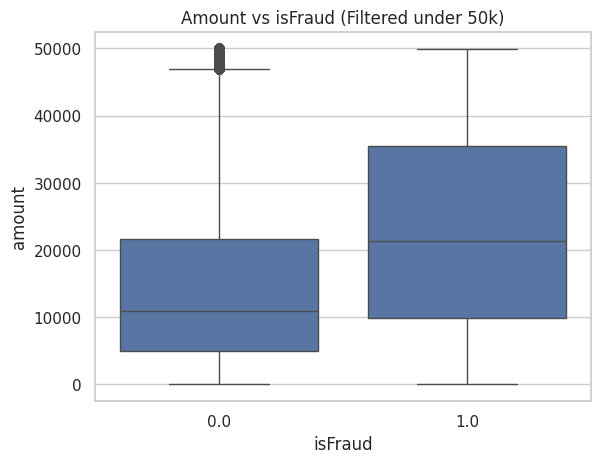

In [74]:
sns.boxplot(data= df[df["amount"] < 50000], x = "isFraud", y="amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

In [75]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [76]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [77]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(1070524)

In [78]:
(df["balanceDiffDest"] < 0).sum()

np.int64(949644)

In [79]:
df.head(2)



,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0


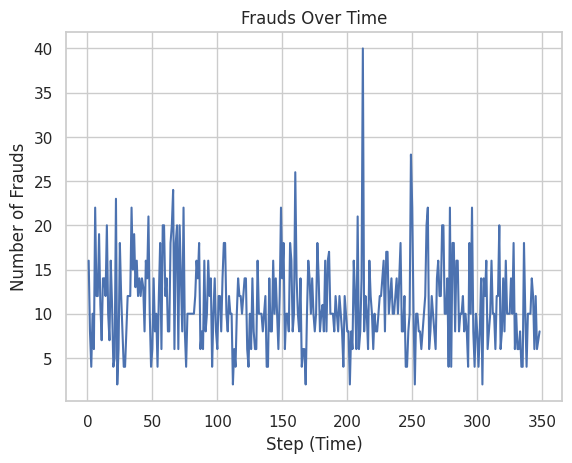

In [80]:
frauds_per_step = df[df["isFraud"] == 1] ["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index , frauds_per_step.values, label="Frauds per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [81]:
df.drop(columns="step",inplace=True)

In [82]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


In [83]:
top_senders = df["nameOrig"].value_counts().head(10)

In [84]:
top_senders

,count
nameOrig,
C1065307291,3
C1530544995,3
C400299098,3
C1999539787,3
C1677795071,3
C1784010646,3
C1976208114,3
C1589272245,2
C887510602,2


In [85]:
top_receivers = df["nameDest"].value_counts().head(10)

In [86]:
top_receivers

,count
nameDest,
C1286084959,110
C985934102,107
C665576141,105
C2083562754,100
C1590550415,99
C248609774,98
C451111351,97
C1789550256,96
C1360767589,94


In [87]:
fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)

In [88]:
fraud_users

,count
nameOrig,
C1347324613,1
C1305486145,1
C840083671,1
C1420196421,1
C2101527076,1
C137533655,1
C1118430673,1
C749981943,1
C1334405552,1


In [89]:
fraud_types = df[df["type"].isin(["TRANSFER","CASH_OUT"])]


In [90]:
fraud_types["type"].value_counts()

,count
type,
CASH_OUT,1728171
TRANSFER,405246


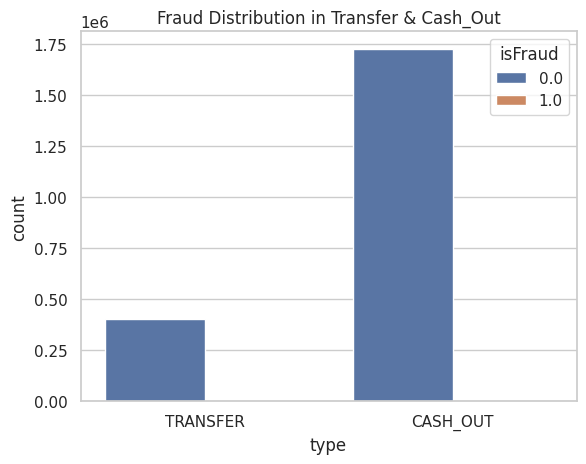

In [91]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud Distribution in Transfer & Cash_Out")
plt.show()

In [92]:
corr = df[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]].corr()

In [93]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.006971,-0.009185,0.350702,0.534332,0.050418
oldbalanceOrg,-0.006971,1.000000,0.999118,0.069140,0.041055,0.005571
newbalanceOrig,-0.009185,0.999118,1.000000,0.070654,0.040908,-0.007428
oldbalanceDest,0.350702,0.069140,0.070654,1.000000,0.968294,-0.005498
newbalanceDest,0.534332,0.041055,0.040908,0.968294,1.000000,-0.000415
isFraud,0.050418,0.005571,-0.007428,-0.005498,-0.000415,1.000000


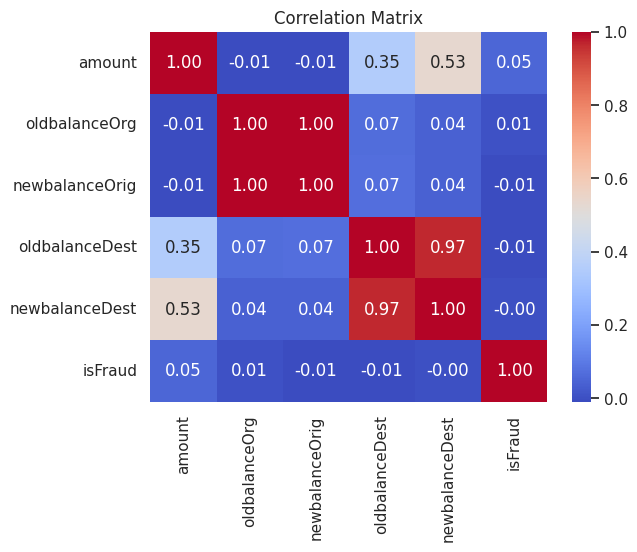

In [94]:
sns. heatmap(corr, annot=True, cmap = "coolwarm", fmt= ".2f")
plt.title("Correlation Matrix")
plt. show()

In [95]:
zero_after_transfer = df[
(df["oldbalanceOrg"] > 0) &
(df["newbalanceOrig"] == 0 ) &
(df["type"].isin(["TRANSFER","CASH_OUT"]))
]

In [96]:
len(zero_after_transfer)

905970

In [97]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1.0,0.0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1.0,0.0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0.0,0.0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0.0,0.0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0.0,0.0,10835.0,2712905.89


In [98]:
df["isFraud"].value_counts()


,count
isFraud,
0.0,4879112
1.0,3869


In [99]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn. linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn. compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [100]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


In [101]:

categorical = ["type"]

numeric = ["amount","oldbalanceOrg","newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

In [102]:
df_model = df[["type", "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]]

In [103]:
y = df_model["isFraud"]
X = df_model.drop("isFraud",axis = 1)

In [105]:
# Clean missing values from the dataframe
df_clean = df.dropna(subset=["isFraud"])

# Re-create model subset
df_model = df_clean[["type", "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]]

# Define X and y
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis=1)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [106]:
preprocessor = ColumnTransformer(
  transformers= [
       ("num", StandardScaler(), numeric),
       ("cat", OneHotEncoder(drop="first"), categorical)
  ],
remainder= "drop"
)

In [107]:
pipeline = Pipeline([
("prep", preprocessor),
("clf",LogisticRegression(class_weight="balanced", max_iter=1000))
])


In [108]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [109]:
y_pred= pipeline.predict(X_test)

In [110]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97   1463734
         1.0       0.02      0.95      0.03      1161

    accuracy                           0.95   1464895
   macro avg       0.51      0.95      0.50   1464895
weighted avg       1.00      0.95      0.97   1464895



In [111]:
confusion_matrix(y_test,y_pred)

array([[1391582,   72152],
       [     55,    1106]])

In [112]:
pipeline.score(X_test,y_test) *100

95.07084125483397

In [113]:
import joblib
joblib.dump(pipeline,"fraud_detection_pipeline.pkl")


['fraud_detection_pipeline.pkl']